# EDA: продажи и Telegram-публикации

In [1]:
from pathlib import Path
import json
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

BASE_URL = "https://raw.githubusercontent.com/valentinesvev/hackaton_project/main/data/raw/base.csv"
TG_URL = "https://raw.githubusercontent.com/valentinesvev/hackaton_project/main/data/raw/tg_posts_text.json"

# При запуске из data/processed/ картинки попадут в ../../outputs/charts.
# В Colab будет создана локальная outputs/charts.
repo_root = Path.cwd()
if (repo_root / "data").exists():
    CHART_DIR = repo_root / "outputs" / "charts"
elif repo_root.name == "processed":
    CHART_DIR = repo_root.parents[1] / "outputs" / "charts"
else:
    CHART_DIR = repo_root / "outputs" / "charts"

CHART_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR

PosixPath('/content/outputs/charts')

## 1. Продажи: загрузка и очистка

In [2]:
base = pd.read_csv(BASE_URL)

required = {"Номер студента", "Сумма", "Курс", "Время"}
missing = required - set(base.columns)
assert not missing, f"Не хватает колонок: {missing}"

sales = base.copy()

sales["Сумма"] = pd.to_numeric(
    sales["Сумма"]
        .astype(str)
        .str.replace(r"[\s\u00a0]", "", regex=True)
        .str.replace(",", ".", regex=False),
    errors="raise",
)

sales["Время"] = pd.to_datetime(
    sales["Время"],
    format="%d.%m.%Y %H:%M:%S",
    errors="raise",
)

sales["Курс"] = sales["Курс"].astype(str).str.strip()

print("Строк:", len(sales))
print("Период:", sales["Время"].min(), "—", sales["Время"].max())
print("Пропуски:")
display(sales.isna().sum().to_frame("missing"))
display(sales.head())

Строк: 795
Период: 2026-08-04 09:08:31 — 2026-09-10 06:09:12
Пропуски:


,missing
Номер студента,0
Сумма,0
Курс,0
Время,0


,Номер студента,Сумма,Курс,Время
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06


### Уровень заказа

Одна строка исходной таблицы — не обязательно отдельная покупка. Если один студент в один timestamp имеет несколько курсов, это bundle: несколько `order_item` внутри одного заказа.

Поэтому:
- выручку по продуктам можно считать по исходным строкам;
- число заказов, средний чек заказа и repeat purchase нужно считать по агрегированной таблице `orders`.

In [3]:
orders = (
    sales
    .groupby(["Номер студента", "Время"], as_index=False)
    .agg(
        order_amount=("Сумма", "sum"),
        courses=("Курс", list),
        n_items=("Курс", "size"),
    )
    .sort_values(["Номер студента", "Время"])
)

orders["order_id"] = np.arange(1, len(orders) + 1)
orders["purchase_number"] = orders.groupby("Номер студента").cumcount() + 1
orders["is_repeat"] = orders["purchase_number"] > 1
orders["date"] = orders["Время"].dt.floor("D")

assert np.isclose(orders["order_amount"].sum(), sales["Сумма"].sum())
assert len(orders) == sales[["Номер студента", "Время"]].drop_duplicates().shape[0]

display(orders.head())

,Номер студента,Время,order_amount,courses,n_items,order_id,purchase_number,is_repeat,date
0,1,2026-09-04 19:30:57,8950.0,[Аналитика старт],1,1,1,False,2026-09-04
1,2,2026-09-05 16:22:48,8950.0,[ML про],1,2,1,False,2026-09-05
2,3,2026-09-03 22:47:02,5975.0,[АВ тестам],1,3,1,False,2026-09-03
3,4,2026-08-31 15:42:34,8950.0,[AI агенты],1,4,1,False,2026-08-31
4,5,2026-08-22 16:19:00,5750.0,[ML про],1,5,1,False,2026-08-22


## 2. Основные метрики

In [17]:
metrics = pd.Series({
    "Строк продуктов": len(sales),
    "Заказов": len(orders),
    "Уникальных покупателей": orders["Номер студента"].nunique(),
    "Продуктов": sales["Курс"].nunique(),
    "Выручка, ₽": orders["order_amount"].sum(),
    "Средний чек заказа, ₽": orders["order_amount"].mean(),
    "Медианный чек заказа, ₽": orders["order_amount"].median(),
    "Bundle-заказов": (orders["n_items"] > 1).sum(),
    "Повторных покупателей": (orders.groupby("Номер студента").size() > 1).sum(),
})

repeat_share = (
    (orders.groupby("Номер студента").size() > 1).mean() * 100
)

summary = pd.DataFrame({
    "Метрика": [
        "Строк продуктов",
        "Заказов",
        "Уникальных покупателей",
        "Продуктов",
        "Выручка, ₽",
        "Средний чек заказа, ₽",
        "Медианный чек заказа, ₽",
        "Bundle-заказов",
        "Повторных покупателей",
        "Доля повторных покупателей, %",
    ],
    "Значение": [
        len(sales),
        len(orders),
        orders["Номер студента"].nunique(),
        sales["Курс"].nunique(),
        round(orders["order_amount"].sum(), 2),
        round(orders["order_amount"].mean(), 2),
        round(orders["order_amount"].median(), 2),
        (orders["n_items"] > 1).sum(),
        (orders.groupby("Номер студента").size() > 1).sum(),
        round(repeat_share, 2),
    ],
})

display(summary)

,Метрика,Значение
0,Строк продуктов,795.00
1,Заказов,628.00
2,Уникальных покупателей,606.00
3,Продуктов,18.00
4,"Выручка, ₽",5904671.67
5,"Средний чек заказа, ₽",9402.34
6,"Медианный чек заказа, ₽",8950.00
7,Bundle-заказов,153.00
8,Повторных покупателей,20.00
9,"Доля повторных покупателей, %",3.30


## 3. Продукты и выручка

,Курс,revenue,item_rows,buyers
11,Аналитика про,740941.50,93,92
5,ML про,715110.00,90,90
0,AI агенты,711673.00,91,90
12,Аналитика старт,641616.50,91,91
10,Алгоритмы старт,529851.68,88,88
6,ML старт,523278.33,80,80
1,Backend про,438342.50,55,55
9,Алгоритмы про,268409.00,35,35
2,Backend старт,263396.66,39,39
8,Алгоритмы,209482.50,30,30


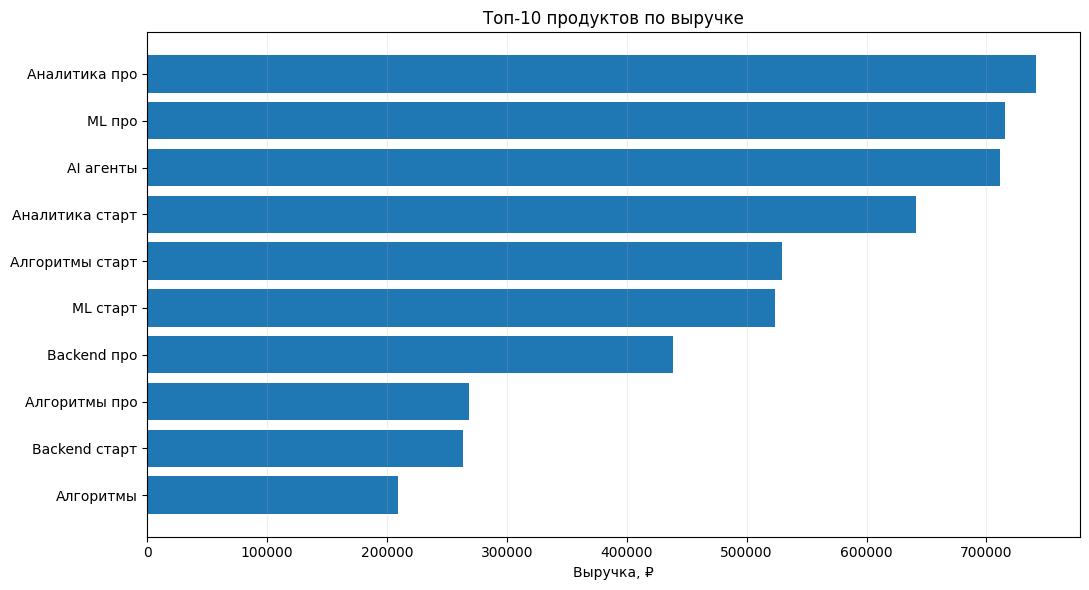

In [5]:
product_summary = (
    sales.groupby("Курс", as_index=False)
    .agg(
        revenue=("Сумма", "sum"),
        item_rows=("Курс", "size"),
        buyers=("Номер студента", "nunique"),
    )
    .sort_values("revenue", ascending=False)
)

display(product_summary)

fig, ax = plt.subplots(figsize=(11, 6))
top = product_summary.head(10).sort_values("revenue")
ax.barh(top["Курс"], top["revenue"])
ax.set_title("Топ-10 продуктов по выручке")
ax.set_xlabel("Выручка, ₽")
ax.set_ylabel("")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
fig.savefig(CHART_DIR / "product_revenue.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Динамика спроса внутри доступного периода

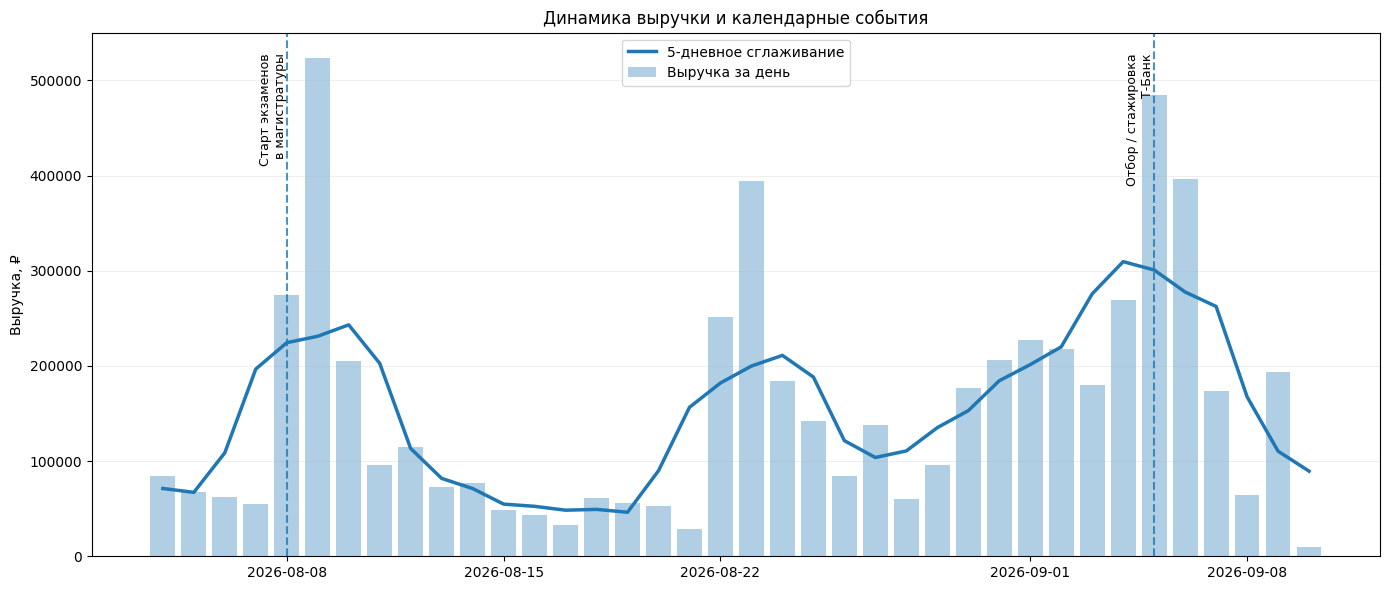

In [6]:
daily = (
    orders.groupby("date", as_index=False)
    .agg(
        revenue=("order_amount", "sum"),
        orders=("order_id", "count"),
        buyers=("Номер студента", "nunique"),
    )
)

calendar = pd.DataFrame({
    "date": pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
})
daily = calendar.merge(daily, on="date", how="left").fillna(
    {"revenue": 0, "orders": 0, "buyers": 0}
)

daily["revenue_ma5"] = daily["revenue"].rolling(5, center=True, min_periods=1).mean()
daily["orders_ma5"] = daily["orders"].rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(daily["date"], daily["revenue"], alpha=.35, label="Выручка за день")
ax.plot(daily["date"], daily["revenue_ma5"], linewidth=2.5, label="5-дневное сглаживание")

# Известные внешние события — контекст, не доказательство причинности.
events_calendar = {
    pd.Timestamp("2026-08-08"): "Старт экзаменов\nв магистратуры",
    pd.Timestamp("2026-09-05"): "Отбор / стажировка\nТ-Банк",
}
for dt, label in events_calendar.items():
    ax.axvline(dt, linestyle="--", alpha=.8)
    ax.text(dt, ax.get_ylim()[1] * .96, label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Динамика выручки и календарные события")
ax.set_ylabel("Выручка, ₽")
ax.set_xlabel("")
ax.grid(axis="y", alpha=.2)
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "sales_demand_profile.png", dpi=160, bbox_inches="tight")
plt.show()

### Как интерпретировать этот график

Сглаженная линия показывает изменение спроса внутри 38-дневного периода. Вертикальные линии — известные внешние события, которые могут совпадать с изменением спроса.

Это **не оценка сезонности в строгом смысле**: для годовой сезонности нужен более длинный ряд, желательно несколько циклов. Здесь корректнее говорить о календарном спросе / demand pattern в доступном периоде.

## 5. Повторные покупки — после исправления bundle

,buyers
n_orders,
1,586
2,19
4,1


,days_since_prev
count,22.000000
mean,13.242406
std,10.380178
min,0.018391
25%,2.588492
50%,12.943397
75%,23.865185
max,28.527859


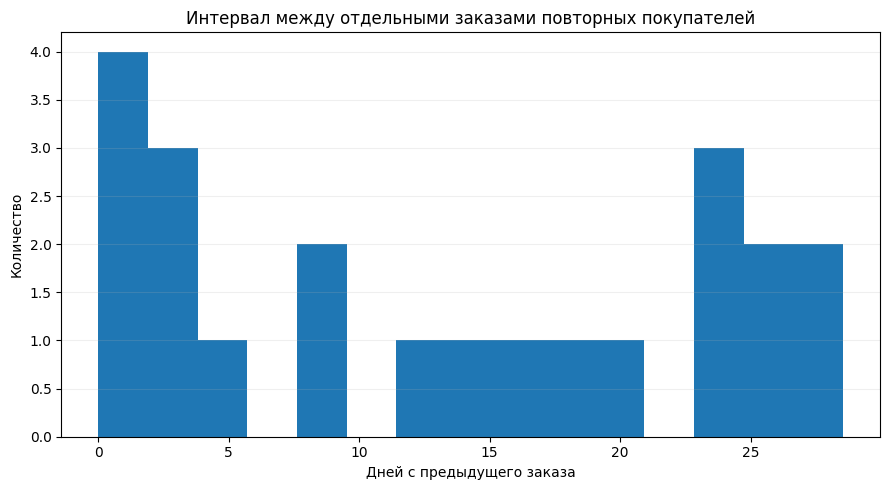

In [7]:
buyer_orders = (
    orders.groupby("Номер студента")
    .agg(
        n_orders=("order_id", "count"),
        first_order=("Время", "min"),
        last_order=("Время", "max"),
        revenue=("order_amount", "sum"),
    )
)

repeat_buyers = buyer_orders[buyer_orders["n_orders"] > 1]

# Интервалы только между РАЗНЫМИ заказами.
order_times = orders[["Номер студента", "Время", "purchase_number"]].copy()
order_times["prev_time"] = order_times.groupby("Номер студента")["Время"].shift(1)
order_times["days_since_prev"] = (
    order_times["Время"] - order_times["prev_time"]
).dt.total_seconds() / 86400

display(buyer_orders["n_orders"].value_counts().sort_index().rename("buyers"))
display(order_times.loc[order_times["purchase_number"] > 1, "days_since_prev"].describe())

fig, ax = plt.subplots(figsize=(9, 5))
vals = order_times.loc[order_times["purchase_number"] > 1, "days_since_prev"].dropna()
ax.hist(vals, bins=min(15, max(5, len(vals))))
ax.set_title("Интервал между отдельными заказами повторных покупателей")
ax.set_xlabel("Дней с предыдущего заказа")
ax.set_ylabel("Количество")
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(CHART_DIR / "repeat_purchase_interval.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Telegram: загрузка и нормализация

In [8]:
response = requests.get(TG_URL, timeout=30)
response.raise_for_status()
tg_raw = response.json()

assert isinstance(tg_raw, dict) and "messages" in tg_raw
tg = pd.DataFrame(tg_raw["messages"])

def clean_text(value):
    if isinstance(value, str):
        return value
    if isinstance(value, list):
        parts = []
        for item in value:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(str(item.get("text", "")))
        return "".join(parts)
    return ""

posts = pd.DataFrame({
    "post_id": tg["id"],
    "event_timestamp": pd.to_datetime(tg["date"], errors="coerce"),
    "post_text": tg["text"].apply(clean_text),
})

posts = posts.dropna(subset=["event_timestamp"]).copy()

analysis_start = orders["Время"].min().floor("D")
analysis_end = orders["Время"].max().ceil("D") + pd.Timedelta(days=1)

analysis_posts = posts[
    (posts["event_timestamp"] >= analysis_start) &
    (posts["event_timestamp"] < analysis_end)
].copy()

analysis_posts["date"] = analysis_posts["event_timestamp"].dt.floor("D")

print("Всего сообщений в выгрузке:", len(posts))
print("Постов в периоде продаж:", len(analysis_posts))
display(analysis_posts.head())

Всего сообщений в выгрузке: 1229
Постов в периоде продаж: 64


,post_id,event_timestamp,post_text,date
1165,1829,2026-08-04 18:50:24,"C какими айтишницами стоит строить отношения, а какие - ред флаг? В новом ролике разобрал все бигтехи по фактам: Янд...",2026-08-04
1166,1830,2026-08-05 19:03:53,Как повысить профессиональный рейтинг \n\nРаньше было достаточно откликнуться на вакансию в красном демоне и ждать п...,2026-08-05
1167,1831,2026-08-06 19:23:59,Какие пет проекты гарантирует тебе оффер на мл-инженера? Обсудим в новом ролике. Смотрим! Смотрим!\n\nhttps://www.yo...,2026-08-06
1168,1833,2026-08-07 17:22:16,Слив алгоритмического собеса в Авито. Смотрим! Смотрим! \n\nhttps://www.youtube.com/watch?v=dO8fHARGgZY&sttick=0\n\n...,2026-08-07
1169,1834,2026-08-08 09:05:37,"Магистратура по e-commerce от РУДН и Wildberries — для тех, кто хочет развиваться в электронной коммерции\nПрограмма...",2026-08-08


## 7. Rule-based классификация постов

In [9]:
PRODUCTS = sorted(sales["Курс"].dropna().unique(), key=len, reverse=True)

discount_keywords = [
    "скидка", "промокод", "распродажа", "спецпредложение"
]
sale_keywords = [
    "старт продаж", "открыли продажи", "набор на курс", "записаться",
    "купить курс", "наш курс", "наши курсы", "курс стартует"
]
external_companies = [
    "яндекс", "авито", "т-банк", "сбер", "рудн", "wildberries", "hh.ru", "linkedin"
]
external_context = [
    "стажиров", "ваканси", "отбор", "олимпиад", "магистратур",
    "программа", "мероприят"
]

def classify_post(text):
    t = str(text).lower()

    product = next((p for p in PRODUCTS if p.lower() in t), None)

    discount = (
        any(k in t for k in discount_keywords)
        or bool(re.search(r"\b\d{1,2}\s?%\b", t))
    )
    external = (
        any(k in t for k in external_companies)
        and any(k in t for k in external_context)
    )
    sale = any(k in t for k in sale_keywords)

    # Приоритет намеренно явный.
    if discount:
        post_type = "discount"
    elif external:
        post_type = "external_mention"
    elif sale:
        post_type = "sale"
    elif product:
        post_type = "product_content"
    else:
        post_type = "content"

    return pd.Series({
        "post_type": post_type,
        "product": product,
    })

classified = analysis_posts.join(
    analysis_posts["post_text"].apply(classify_post)
)

display(classified["post_type"].value_counts().rename("posts"))
display(classified[["event_timestamp", "post_type", "product", "post_text"]].head(15))

,posts
post_type,
content,34
external_mention,23
discount,3
sale,3
product_content,1


,event_timestamp,post_type,product,post_text
1165,2026-08-04 18:50:24,content,None,"C какими айтишницами стоит строить отношения, а какие - ред флаг? В новом ролике разобрал все бигтехи по фактам: Янд..."
1166,2026-08-05 19:03:53,external_mention,None,Как повысить профессиональный рейтинг \n\nРаньше было достаточно откликнуться на вакансию в красном демоне и ждать п...
1167,2026-08-06 19:23:59,content,None,Какие пет проекты гарантирует тебе оффер на мл-инженера? Обсудим в новом ролике. Смотрим! Смотрим!\n\nhttps://www.yo...
1168,2026-08-07 17:22:16,external_mention,Алгоритмы старт,Слив алгоритмического собеса в Авито. Смотрим! Смотрим! \n\nhttps://www.youtube.com/watch?v=dO8fHARGgZY&sttick=0\n\n...
1169,2026-08-08 09:05:37,discount,None,"Магистратура по e-commerce от РУДН и Wildberries — для тех, кто хочет развиваться в электронной коммерции\nПрограмма..."
1170,2026-08-09 13:32:11,discount,None,"Дайджест вакансий\n\nТоварищи, собрали свежие стажировки и junior-вакансии по аналитике, ML и разработке. Сохраняйте..."
1171,2026-08-09 18:35:40,external_mention,Алгоритмы,"Как найти стажировку зарубежом\n\nТоварищи, пока идут последние 6 часов финальной распродажи на СТАРТ, хотим напомни..."
1172,2026-08-10 16:26:59,content,None,"Из процесс-менеджера в продуктового аналитика \n\nДрузья, видим ваши вопросы, можно ли ещё взять СТАРТ по скидке. По..."
1173,2026-08-10 16:26:59,content,None,
1174,2026-08-10 20:33:06,sale,None,"У России три пути: 18+, ***** и IT\n\nИ кажется, у нас случился переход между карьерными треками…\nНам неважно, како..."


**Важно:** `external_mention` означает только, что rule-based классификатор нашёл в тексте внешнюю компанию и релевантный контекст. Это **не подтверждённое платное внешнее размещение**.

## 8. Продажи и Telegram-посты на одной временной шкале

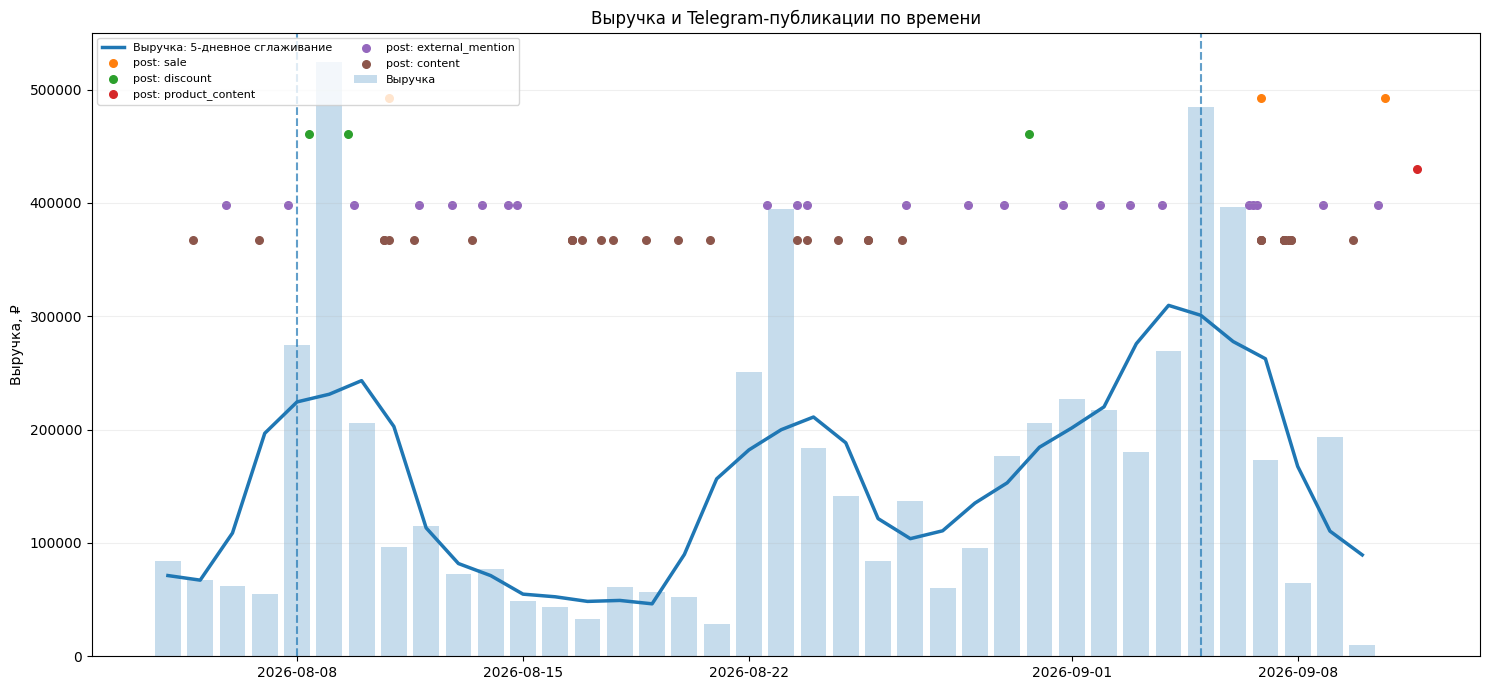

In [10]:
posts_daily = (
    classified.groupby(["date", "post_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

combined = daily.merge(posts_daily, on="date", how="left").fillna(0)

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(combined["date"], combined["revenue"], alpha=.25, label="Выручка")
ax.plot(
    combined["date"],
    combined["revenue_ma5"],
    linewidth=2.5,
    label="Выручка: 5-дневное сглаживание"
)

# Отмечаем сами публикации на уровне временной шкалы.
y_top = max(combined["revenue"].max(), 1)
marker_levels = {
    "sale": .94,
    "discount": .88,
    "product_content": .82,
    "external_mention": .76,
    "content": .70,
}

for post_type, level in marker_levels.items():
    subset = classified[classified["post_type"] == post_type]
    if len(subset):
        ax.scatter(
            subset["event_timestamp"],
            np.full(len(subset), y_top * level),
            s=30,
            label=f"post: {post_type}",
        )

for dt, label in events_calendar.items():
    ax.axvline(dt, linestyle="--", alpha=.7)

ax.set_title("Выручка и Telegram-публикации по времени")
ax.set_ylabel("Выручка, ₽")
ax.set_xlabel("")
ax.grid(axis="y", alpha=.2)
ax.legend(ncol=2, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(CHART_DIR / "posts_sales.png", dpi=160, bbox_inches="tight")
plt.show()

Этот график — основная иллюстрация совместной динамики. Он позволяет увидеть, какие публикации выходили рядом со всплесками продаж, но не позволяет утверждать, что пост вызвал покупку: публикации частые, события перекрываются, а user-level source исторически отсутствует.

## 9. Event-study: продажи вокруг маркетинговых постов

,revenue_24h_before,revenue_24h_after,revenue_24_48h_after
post_type,,,
discount,165415.0,282750.0,190635.0
product_content,0.0,0.0,0.0
sale,215490.0,96330.0,64750.0


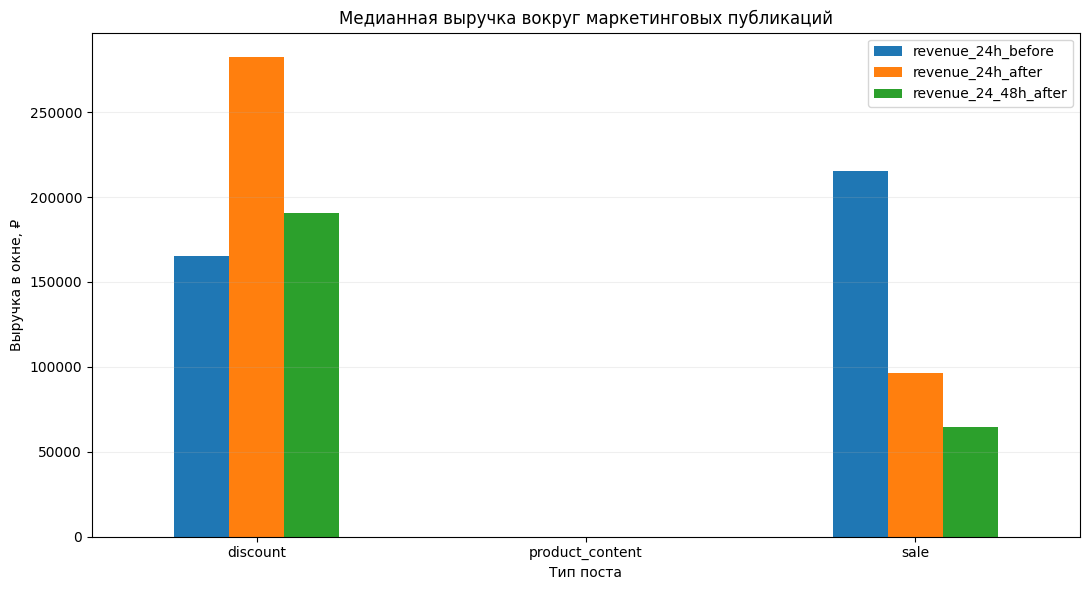

In [11]:
# Берём только типы, которые разумно рассматривать как маркетинговые события.
marketing_types = ["sale", "discount", "product_content"]
marketing_posts = classified[classified["post_type"].isin(marketing_types)].copy()

# Для каждого поста считаем revenue/orders в фиксированных окнах относительно точного времени публикации.
# Это описательная диагностика. Окна разных постов могут перекрываться.
def window_stats(post_ts):
    out = {}
    windows = {
        "24h_before": (post_ts - pd.Timedelta(hours=24), post_ts),
        "24h_after": (post_ts, post_ts + pd.Timedelta(hours=24)),
        "24_48h_after": (post_ts + pd.Timedelta(hours=24), post_ts + pd.Timedelta(hours=48)),
    }
    for name, (left, right) in windows.items():
        mask = (orders["Время"] >= left) & (orders["Время"] < right)
        out[f"revenue_{name}"] = orders.loc[mask, "order_amount"].sum()
        out[f"orders_{name}"] = int(mask.sum())
    return pd.Series(out)

if len(marketing_posts):
    event_study = marketing_posts.join(
        marketing_posts["event_timestamp"].apply(window_stats)
    )

    display(
        event_study.groupby("post_type")[
            ["revenue_24h_before", "revenue_24h_after", "revenue_24_48h_after"]
        ].median().round(0)
    )

    event_plot = (
        event_study.groupby("post_type")[
            ["revenue_24h_before", "revenue_24h_after", "revenue_24_48h_after"]
        ]
        .median()
    )

    ax = event_plot.plot(kind="bar", figsize=(11, 6))
    ax.set_title("Медианная выручка вокруг маркетинговых публикаций")
    ax.set_ylabel("Выручка в окне, ₽")
    ax.set_xlabel("Тип поста")
    ax.grid(axis="y", alpha=.2)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(CHART_DIR / "post_event_study.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Маркетинговые посты не найдены классификатором.")

### Ограничение event-study

Сравнение «24 часа до / после» полезно как sanity check, но **не является оценкой incremental lift**:
- посты могут выходить близко друг к другу;
- публикации могут планироваться именно на периоды ожидаемого спроса;
- на продажи влияют внешние события;
- неизвестно, видел ли конкретный покупатель конкретный пост.

Поэтому результат следует описывать как temporal association.

## 10. Дневная таблица: продажи + посты

In [12]:
daily_posts_total = (
    classified.groupby("date")
    .size()
    .rename("posts_total")
    .reset_index()
)

daily_marketing = (
    classified[classified["post_type"].isin(marketing_types)]
    .groupby("date")
    .size()
    .rename("marketing_posts")
    .reset_index()
)

daily_joined = (
    daily
    .merge(daily_posts_total, on="date", how="left")
    .merge(daily_marketing, on="date", how="left")
    .fillna({"posts_total": 0, "marketing_posts": 0})
)

daily_joined["posts_total"] = daily_joined["posts_total"].astype(int)
daily_joined["marketing_posts"] = daily_joined["marketing_posts"].astype(int)

display(daily_joined.head(15))

,date,revenue,orders,buyers,revenue_ma5,orders_ma5,posts_total,marketing_posts
0,2026-08-04,84130.00,7,6,71228.333333,6.666667,1,0
1,2026-08-05,67110.00,6,6,67170.000000,6.250000,1,0
2,2026-08-06,62445.00,7,7,108739.000000,12.000000,1,0
3,2026-08-07,54995.00,5,5,196731.334000,24.200000,1,0
4,2026-08-08,275015.00,35,35,224427.334000,28.800000,1,1
5,2026-08-09,524091.67,68,68,231204.334000,29.800000,2,1
6,2026-08-10,205590.00,29,29,243191.334000,31.600000,4,1
7,2026-08-11,96330.00,12,12,202750.334000,26.400000,2,0
8,2026-08-12,114930.00,14,14,113270.000000,14.600000,1,0
9,2026-08-13,72810.00,9,9,81821.000000,9.800000,2,0


### Почему не стоит считать простую корреляцию `posts_total` ↔ `revenue`

В периоде публикации выходят очень часто, а продажи имеют выраженную временную структуру. Обычная корреляция смешает:
- календарный спрос;
- число публикаций;
- тип публикации;
- внешние события.

Поэтому в EDA лучше оставить временной график и event-study как **описательную** диагностику, а causal effect измерять уже на новых данных через holdout / A/B / randomized promotion.

## 11. Что можно и нельзя заключить из исторических данных

In [13]:
summary = pd.DataFrame({
    "Можно измерить": [
        "Выручку и число заказов",
        "Продуктовый микс",
        "Bundle-заказы и реальные repeat orders",
        "Динамику спроса внутри периода",
        "Даты и типы публикаций собственного Telegram-канала",
        "Временную ассоциацию продаж и публикаций",
    ],
    "Нельзя восстановить надежно": [
        "Какой конкретно пост увидел покупатель",
        "Paid external placement для каждой покупки",
        "Истинный incremental lift поста",
        "Исторический ROMI внешней рекламы",
        "Полную годовую сезонность по 38 дням",
        "Причинность из совпадения поста и всплеска продаж",
    ]
})
display(summary)

,Можно измерить,Нельзя восстановить надежно
0,Выручку и число заказов,Какой конкретно пост увидел покупатель
1,Продуктовый микс,Paid external placement для каждой покупки
2,Bundle-заказы и реальные repeat orders,Истинный incremental lift поста
3,Динамику спроса внутри периода,Исторический ROMI внешней рекламы
4,Даты и типы публикаций собственного Telegram-канала,Полную годовую сезонность по 38 дням
5,Временную ассоциацию продаж и публикаций,Причинность из совпадения поста и всплеска продаж


## Итог

Историческая база хорошо описывает **что купили, когда и на какую сумму**, а Telegram export — **что и когда публиковалось**. После перехода на уровень заказа bundle-строки больше не искажают repeat purchase.

Совмещение по timestamp позволяет визуально и через event-study исследовать временную связь публикаций и продаж. Но исторически отсутствует ключевая связь `placement → user → touch → lead → order`, поэтому attribution ROMI и incremental effect из этого EDA не выводятся.

Именно этот пробел закрывает measurement-flow Telegram-бота: новые кампании должны собирать source/placement и user-level касания с момента запуска.